# Qwen2.5-0.5B-Instruct Türkçe Mobil Action Router LoRA Fine-tuning

Bu notebook, `Qwen/Qwen2.5-0.5B-Instruct` modelini Türkçe mobil komutları function-call JSON formatına çevirmek için LoRA ile fine-tune eder.

Bu çalışma FunctionGemma special-token veya `tool_calls` formatı kullanmaz. Eğitim hedefi basit ve net bir JSON router çıktısıdır:

```json
{"name":"set_alarm","arguments":{"time":"08:00","date":"tomorrow","label":null}}
```

Pipeline:

```text
./csv_datasets/*.csv veya *.xlsx
  -> oku + birleştir
  -> tool_name ve tool_arguments doğrula
  -> Qwen chat messages formatına çevir
  -> LoRA SFT
  -> before/after JSON router evaluation
  -> manual test + inference-only load örneği
```

## 1. Install

Colab'da önerilen runtime: `T4`, `P100 16GB` veya daha iyi bir GPU. Paket kurulumundan sonra runtime restart gerekirse Colab uyarısını takip et. Pro alın yahu.

#### İlk hatayı alırken yükleme için kütüphaneler

In [1]:
!uv pip install -q -U --force-reinstall torch torchvision torchaudio
!uv pip install -q -U transformers datasets accelerate trl peft evaluate sentencepiece protobuf tensorboard pandas openpyxl scikit-learn matplotlib tqdm huggingface_hub numpy scipy

In [2]:
import os
# Fix for 'ImportError: cannot import name _center from numpy._core.umath'
# This usually occurs due to numpy 2.x vs scipy compatibility issues.
!pip install -q "numpy<2.0" "scipy>=1.13"
print("Numpy and Scipy reinstalled. Please restart the session if prompted via 'Runtime' -> 'Restart session' before running the Imports cell.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 111.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.1 which is incompatible.
bigframes 2.39.0 requires rich<14,>=12.4.4, but you have rich 15.0.0 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
cuml-cu12 26.2.0 requires cuda-toolkit[cublas,cufft,curand,cusolver,cusparse]==12.*, but you have cuda-toolkit 13.0.2 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but

In [3]:
!uv pip uninstall torchao bitsandbytes

Using Python 3.12.13 environment at: /usr
Uninstalled 1 package in 112ms
 - torchao==0.10.0


## 2. Imports

In [1]:
from __future__ import annotations

import os
import re
import json
import csv
import random
import inspect
from pathlib import Path
from typing import Any

import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import Dataset
from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM
from transformers import TrainerCallback
from trl import SFTConfig
from trl import SFTTrainer
from peft import LoraConfig
from huggingface_hub import login

try:
    from sklearn.model_selection import train_test_split
except Exception as exc:
    train_test_split = None
    print(f"WARNING: sklearn import edilemedi, fallback split kullanılacak: {exc}")

## 3. Config

In [2]:
BASE_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"
DATA_FOLDER = Path("./csv_datasets")
MERGED_DATASET_PATH = "merged_qwen_mobile_actions_dataset.csv"
CHECKPOINT_DIR = "qwen2_5_0_5b_turkish_mobile_actions"
HUB_MODEL_ID = "BTX24/qwen2_5_0_5b_turkish-mobile-actions"
PUSH_TO_HUB = False

TEST_SIZE = 0.10
RANDOM_SEED = 42
MAX_LENGTH = 384
NUM_TRAIN_EPOCHS = 3
LEARNING_RATE = 2e-4
PER_DEVICE_TRAIN_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 8
EVAL_STEPS = 200
SAVE_STEPS = 200
LOGGING_STEPS = 25

REQUIRED_COLUMNS = ["user_content", "tool_name", "tool_arguments"]
BAD_ROWS_PATH = "bad_rows_qwen_dataset.csv"
ERRORS_AFTER_PATH = "errors_qwen_after_finetune.csv"
METRICS_PATH = "qwen_eval_metrics.json"

SYSTEM_PROMPT = (
    "Sen Türkçe mobil komutları function call JSON formatına çeviren bir modelsin. "
    "Kullanıcıya açıklama yapma. Sadece geçerli JSON üret. "
    "JSON formatı şu olmalı: {\"name\":\"tool_name\",\"arguments\":{...}}. "
    "Eğer bilgi eksikse ask_clarification kullan. "
    "Riskli işlemde request_confirmation kullan."
)

ALLOWED_TOOLS = {
    "set_alarm",
    "set_timer",
    "create_reminder",
    "send_message",
    "call_contact",
    "open_app",
    "change_device_setting",
    "create_note",
    "start_navigation",
    "search_web",
    "ask_clarification",
    "request_confirmation",
}

REQUIRED_ARGS_BY_TOOL = {
    "set_alarm": ["time"],
    "set_timer": ["duration_minutes"],
    "create_reminder": ["text"],
    "send_message": ["recipient", "message"],
    "call_contact": ["recipient"],
    "open_app": ["app_name"],
    "change_device_setting": ["setting", "value"],
    "create_note": ["content"],
    "start_navigation": ["destination"],
    "search_web": ["query"],
    "ask_clarification": ["missing_field", "question"],
    "request_confirmation": ["action", "question"],
}

random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


## 4. Hugging Face Login

Token hardcode edilmez. Colab için `Secrets` bölümüne `HF_TOKEN` ekleyebilirsin. Token yoksa notebook crash olmaz; sadece private/gated model veya Hub push kullanılamaz.

In [3]:
HF_TOKEN = None
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")

if HF_TOKEN:
    login(token=HF_TOKEN)
    print("Hugging Face login tamamlandı.")
else:
    print("WARNING: HF_TOKEN bulunamadı. Public model indirme çalışabilir, Hub push kapalı kalmalı.")

Hugging Face login tamamlandı.


## 5. Dataset Okuma ve Birleştirme

`./csv_datasets/` klasörüne birden fazla CSV veya XLSX dosyası yükleyebilirsin. Eksik kolonlu dosyalar atlanır ve uyarı basılır.

In [5]:
def read_all_dataset_files(data_folder: Path) -> pd.DataFrame:
    """CSV/XLSX dosyalarını okuyup tek DataFrame olarak birleştirir.

    Args:
        data_folder: CSV/XLSX dosyalarının bulunduğu klasör.

    Returns:
        Birleştirilmiş ham DataFrame.
    """
    data_folder.mkdir(parents=True, exist_ok=True)
    files = sorted(data_folder.glob("*.csv")) + sorted(data_folder.glob("*.xlsx"))
    frames: list[pd.DataFrame] = []

    print(f"Dataset klasörü: {data_folder.resolve()}")
    print(f"Bulunan dosya sayısı: {len(files)}")

    for file in files:
        print(f"Okunuyor: {file.name}")
        try:
            if file.suffix.lower() == ".csv":
                df_part = pd.read_csv(
                    file,
                    engine="python",
                    quoting=csv.QUOTE_MINIMAL,
                    escapechar="\\",
                    on_bad_lines="warn",
                    encoding="utf-8",
                    doublequote=True,
                )
                source_type = "csv"
            elif file.suffix.lower() == ".xlsx":
                df_part = pd.read_excel(file, sheet_name=0)
                source_type = "xlsx"
            else:
                continue

            df_part.columns = [str(column).strip() for column in df_part.columns]
            missing = [column for column in REQUIRED_COLUMNS if column not in df_part.columns]
            if missing:
                print(f"  Atlandı, eksik kolonlar: {missing}")
                continue

            df_part = df_part[REQUIRED_COLUMNS].copy()
            #df_part["source_file"] = file.name
            #df_part["source_type"] = source_type
            frames.append(df_part)
            print(f"  Alınan satır: {len(df_part)}")
        except Exception as exc:
            print(f"  Hata, dosya atlandı: {exc}")

    if not frames:
        raise ValueError("Hiç geçerli CSV/XLSX okunamadı. ./csv_datasets klasörünü kontrol et.")

    merged = pd.concat(frames, ignore_index=True)
    print(f"Birleştirilmiş ham satır: {len(merged)}")
    return merged


raw_df = read_all_dataset_files(DATA_FOLDER)
display(raw_df.head())

Dataset klasörü: /content/csv_datasets
Bulunan dosya sayısı: 36
Okunuyor: claude_funtion_calling.csv
  Alınan satır: 936
Okunuyor: claude_request_confirmation.csv
  Alınan satır: 1200
Okunuyor: gemini_alarm_timer.csv
  Alınan satır: 416
Okunuyor: gemini_call.csv
  Alınan satır: 200
Okunuyor: gemini_clarification.csv
  Alınan satır: 199
Okunuyor: gemini_confirmation.csv
  Alınan satır: 200
Okunuyor: gemini_contact.csv
  Alınan satır: 999
Okunuyor: gemini_device_settings.csv
  Alınan satır: 999
Okunuyor: gemini_device_settings_2.csv
  Alınan satır: 199
Okunuyor: gemini_message.csv
  Alınan satır: 1000
Okunuyor: gemini_message_2.csv
  Alınan satır: 148
Okunuyor: gemini_navigation.csv
  Alınan satır: 199
Okunuyor: gemini_notes.csv
  Alınan satır: 200
Okunuyor: gemini_open_app.csv
  Alınan satır: 999
Okunuyor: gemini_open_app_2.csv
  Alınan satır: 200
Okunuyor: gemini_reminder.csv
  Alınan satır: 313
Okunuyor: gemini_reminder2.csv
  Alınan satır: 59
Okunuyor: gemini_search.csv
  Alınan satı

/tmp/ipykernel_1354/3607244356.py:21: ParserWarning: Skipping line 201: unexpected end of data

  df_part = pd.read_csv(
/tmp/ipykernel_1354/3607244356.py:21: ParserWarning: Skipping line 1001: unexpected end of data

  df_part = pd.read_csv(
/tmp/ipykernel_1354/3607244356.py:21: ParserWarning: Skipping line 1001: unexpected end of data

  df_part = pd.read_csv(
/tmp/ipykernel_1354/3607244356.py:21: ParserWarning: Skipping line 201: unexpected end of data

  df_part = pd.read_csv(
/tmp/ipykernel_1354/3607244356.py:21: ParserWarning: Skipping line 20: ',' expected after '"'

  df_part = pd.read_csv(
/tmp/ipykernel_1354/3607244356.py:21: ParserWarning: Skipping line 22: ',' expected after '"'

  df_part = pd.read_csv(
/tmp/ipykernel_1354/3607244356.py:21: ParserWarning: Skipping line 23: ',' expected after '"'

  df_part = pd.read_csv(
/tmp/ipykernel_1354/3607244356.py:21: ParserWarning: Skipping line 25: ',' expected after '"'

  df_part = pd.read_csv(
/tmp/ipykernel_1354/3607244356.py:

,user_content,tool_name,tool_arguments
0,Ahmet'e sms at geç kalacağım,send_message,"{""recipient"":""Ahmet"",""message"":""Geç kalacağım...."
1,Annem'e WhatsApp'tan iyi geceler yaz,send_message,"{""recipient"":""Annem"",""message"":""İyi geceler."",..."
2,Babama telegram'dan yarın görüşürüz de,send_message,"{""recipient"":""Babam"",""message"":""Yarın görüşürü..."
3,Mesaj at,ask_clarification,"{""missing_field"":""recipient_and_message"",""ques..."
4,Selin'e whatsapp mesajı gönder toplantı iptal,send_message,"{""recipient"":""Selin"",""message"":""Toplantı iptal..."


## 6. Dataset Temizlik ve Validation

Bu hücre tool adını, JSON parse edilebilirliğini ve minimum required argument alanlarını kontrol eder. Hatalı satırlar `bad_rows_qwen_dataset.csv` dosyasına yazılır ve bilinçli olarak hata verilir.

In [6]:
TOOL_NAME_ALIASES = {
    "toggle_setting": "change_device_setting",
    "make_call": "call_contact",
    "add_reminder": "create_reminder",
    "navigate_to": "start_navigation",
    "get_weather": "search_web",
    "play_music": "search_web",
    "create_calendar_event": "create_reminder",
}

SETTING_ALIASES = {
    "wifi": "wifi",
    "wi-fi": "wifi",
    "bluetooth": "bluetooth",
    "silent": "silent_mode",
    "silent_mode": "silent_mode",
    "dark": "dark_mode",
    "dark_mode": "dark_mode",
    "airplane": "airplane_mode",
    "airplane_mode": "airplane_mode",
    "do_not_disturb": "do_not_disturb",
    "mobile_data": "mobile_data",
    "location": "location",
    "hotspot": "hotspot",
}

NAV_MODE_ALIASES = {
    "car": "driving",
    "driving": "driving",
    "arabaya": "driving",
    "arabayla": "driving",
    "walking": "walking",
    "yürüyerek": "walking",
    "walk": "walking",
    "transit": "transit",
    "metro": "transit",
    "metroyla": "transit",
    "bus": "transit",
}


def safe_json_loads(value: Any) -> dict[str, Any]:
    if isinstance(value, dict):
        return value
    if value is None:
        return {}
    if isinstance(value, float) and pd.isna(value):
        return {}

    text = str(value).strip()
    if not text or text.lower() == "nan":
        return {}

    parsed = json.loads(text)
    if not isinstance(parsed, dict):
        raise ValueError("tool_arguments JSON object olmalı")
    return parsed


def parse_duration_minutes(value: Any) -> int | None:
    if value is None or value == "":
        return None
    if isinstance(value, int):
        return value
    if isinstance(value, float) and not pd.isna(value):
        return int(value)

    match = re.search(r"\d+", str(value))
    return int(match.group(0)) if match else None


def normalize_tool_and_args(
    tool_name: str,
    args: dict[str, Any],
    user_content: str,
) -> tuple[str, dict[str, Any], str | None]:
    original_tool = tool_name
    tool_name = TOOL_NAME_ALIASES.get(tool_name, tool_name)
    note = f"mapped:{original_tool}->{tool_name}" if original_tool != tool_name else None

    if original_tool == "toggle_setting":
        setting = str(args.get("setting", "")).strip().lower()
        value = args.get("value", args.get("state"))
        value = str(value).strip().lower() if value is not None else ""

        if setting not in SETTING_ALIASES:
            return (
                "request_confirmation",
                {
                    "action": user_content,
                    "question": "Bu ayar desteklenen ayarlar listesinde değil. Yine de bu işlemi yapmak istiyor musun?",
                },
                "mapped:unsupported_setting->request_confirmation",
            )

        return (
            "change_device_setting",
            {"setting": SETTING_ALIASES[setting], "value": value},
            note,
        )

    if original_tool == "make_call":
        return (
            "call_contact",
            {"recipient": args.get("recipient") or args.get("contact") or user_content},
            note,
        )

    if original_tool == "add_reminder":
        return (
            "create_reminder",
            {
                "text": args.get("text") or args.get("task") or user_content,
                "date": args.get("date"),
                "time": args.get("time"),
            },
            note,
        )

    if original_tool == "navigate_to":
        raw_mode = str(args.get("mode") or args.get("transport_mode") or "driving").strip().lower()
        return (
            "start_navigation",
            {
                "destination": args.get("destination") or user_content,
                "mode": NAV_MODE_ALIASES.get(raw_mode, "driving"),
            },
            note,
        )

    if original_tool == "get_weather":
        location = args.get("location", "")
        day = args.get("day", "")
        query = " ".join(str(part) for part in [location, day, "hava durumu"] if str(part).strip())
        return "search_web", {"query": query or user_content}, note

    if original_tool == "play_music":
        artist = args.get("artist", "")
        song = args.get("song", "")
        genre = args.get("genre", "")
        query = " ".join(str(part) for part in [artist, song, genre, "müzik"] if str(part).strip())
        return "search_web", {"query": query or user_content}, note

    if original_tool == "create_calendar_event":
        title = args.get("title") or user_content
        return (
            "create_reminder",
            {
                "text": title,
                "date": args.get("date"),
                "time": args.get("time"),
            },
            note,
        )

    if original_tool == "take_photo":
        return (
            "request_confirmation",
            {
                "action": user_content,
                "question": "Kamerayı açıp fotoğraf çekmemi onaylıyor musun?",
            },
            "mapped:take_photo->request_confirmation",
        )

    if original_tool == "send_email":
        recipient = args.get("recipient") or args.get("to") or "unknown"
        subject = args.get("subject")
        body = args.get("body") or args.get("message") or user_content

        action_text = f"E-posta gönder: alıcı={recipient}"
        if subject:
            action_text += f", konu={subject}"
        if body:
            action_text += f", içerik={body}"

        return (
            "request_confirmation",
            {
                "action": action_text,
                "question": "Bu e-postayı göndermemi onaylıyor musun?",
            },
            "mapped:send_email->request_confirmation",
        )

    if tool_name == "set_timer" and "duration_minutes" not in args:
        minutes = parse_duration_minutes(args.get("duration"))
        if minutes is not None:
            args = {**args, "duration_minutes": minutes}
            args.pop("duration", None)

    if tool_name == "send_message":
        if "recipient" not in args and "contact" in args:
            args = {**args, "recipient": args.get("contact")}
        if "app" not in args:
            args = {**args, "app": "sms"}

    if tool_name == "call_contact" and "recipient" not in args and "contact" in args:
        args = {"recipient": args.get("contact")}

    if tool_name == "create_reminder" and "text" not in args and "task" in args:
        args = {
            "text": args.get("task"),
            "date": args.get("date"),
            "time": args.get("time"),
        }

    if tool_name == "start_navigation" and "mode" not in args:
        args = {**args, "mode": "driving"}

    return tool_name, args, note


def validate_args_by_tool(tool_name: str, args: dict[str, Any]) -> None:
    required_fields = REQUIRED_ARGS_BY_TOOL.get(tool_name, [])
    missing = [
        field
        for field in required_fields
        if field not in args or args[field] is None or args[field] == ""
    ]
    if missing:
        raise ValueError(f"Eksik required alanlar: {missing}")


def clean_and_validate_dataset(raw_df: pd.DataFrame) -> pd.DataFrame:
    df = raw_df.copy()

    for column in REQUIRED_COLUMNS:
        df[column] = df[column].astype(str).str.strip()

    before = len(df)
    for column in REQUIRED_COLUMNS:
        df = df[(df[column] != "") & (df[column].str.lower() != "nan")]
    print(f"Boş/nan satır temizliği: {before - len(df)} satır atıldı")

    before = len(df)
    df = df.drop_duplicates(subset=REQUIRED_COLUMNS).reset_index(drop=True)
    print(f"Duplicate temizliği: {before - len(df)} satır atıldı")

    df["tool_name"] = (
        df["tool_name"]
        .str.replace("\u200b", "", regex=False)
        .str.replace("\ufeff", "", regex=False)
        .str.replace(r"\s+", "_", regex=True)
    )

    valid_rows = []
    bad_rows = []
    normalization_notes = []

    for _, row in df.iterrows():
        row_dict = row.to_dict()
        raw_tool_name = row_dict["tool_name"]
        reason = None

        try:
            parsed_args = safe_json_loads(row_dict["tool_arguments"])
            tool_name, normalized_args, note = normalize_tool_and_args(
                raw_tool_name,
                parsed_args,
                row_dict["user_content"],
            )

            if tool_name not in ALLOWED_TOOLS:
                raise ValueError(f"Allowed tools içinde yok: {tool_name}")

            validate_args_by_tool(tool_name, normalized_args)

            row_dict["original_tool_name"] = raw_tool_name
            row_dict["tool_name"] = tool_name
            row_dict["tool_arguments"] = json.dumps(
                normalized_args,
                ensure_ascii=False,
                separators=(",", ":"),
            )
            row_dict["normalization_note"] = note

            valid_rows.append(row_dict)
            if note:
                normalization_notes.append(note)

        except Exception as exc:
            reason = str(exc)

        if reason:
            bad_item = row.to_dict()
            bad_item["error"] = reason
            bad_rows.append(bad_item)

    if normalization_notes:
        print("Normalize edilen satır sayısı:", len(normalization_notes))
        print(pd.Series(normalization_notes).value_counts())

    if bad_rows:
        bad_rows_df = pd.DataFrame(bad_rows)
        bad_rows_df.to_csv(BAD_ROWS_PATH, index=False, encoding="utf-8-sig")

        print(f"Hatalı satır sayısı: {len(bad_rows_df)}")
        print(f"Hatalı satırlar kaydedildi: {BAD_ROWS_PATH}")
        display(bad_rows_df.head(30))

        raise ValueError(
            "Dataset validation hâlâ başarısız. Kalan satırlar gerçekten manuel karar istiyor."
        )

    clean_df = pd.DataFrame(valid_rows).reset_index(drop=True)
    clean_df.to_csv(MERGED_DATASET_PATH, index=False, encoding="utf-8-sig")

    print(f"Temiz dataset satır sayısı: {len(clean_df)}")
    print(f"Kaydedildi: {MERGED_DATASET_PATH}")

    return clean_df


df = clean_and_validate_dataset(raw_df)
display(df.head())

Boş/nan satır temizliği: 0 satır atıldı
Duplicate temizliği: 6169 satır atıldı
Normalize edilen satır sayısı: 34
mapped:toggle_setting->change_device_setting        5
mapped:play_music->search_web                       5
mapped:get_weather->search_web                      4
mapped:add_reminder->create_reminder                4
mapped:navigate_to->start_navigation                4
mapped:unsupported_setting->request_confirmation    4
mapped:make_call->call_contact                      3
mapped:create_calendar_event->create_reminder       3
mapped:take_photo->request_confirmation             1
mapped:send_email->request_confirmation             1
Name: count, dtype: int64
Temiz dataset satır sayısı: 17826
Kaydedildi: merged_qwen_mobile_actions_dataset.csv


,user_content,tool_name,tool_arguments,original_tool_name,normalization_note
0,Ahmet'e sms at geç kalacağım,send_message,"{""recipient"":""Ahmet"",""message"":""Geç kalacağım....",send_message,NaN
1,Annem'e WhatsApp'tan iyi geceler yaz,send_message,"{""recipient"":""Annem"",""message"":""İyi geceler."",...",send_message,NaN
2,Babama telegram'dan yarın görüşürüz de,send_message,"{""recipient"":""Babam"",""message"":""Yarın görüşürü...",send_message,NaN
3,Mesaj at,ask_clarification,"{""missing_field"":""recipient_and_message"",""ques...",ask_clarification,NaN
4,Selin'e whatsapp mesajı gönder toplantı iptal,send_message,"{""recipient"":""Selin"",""message"":""Toplantı iptal...",send_message,NaN


## 7. Veri Dağılımı

Tool dağılımı:
tool_name
ask_clarification        1686
call_contact             1327
change_device_setting    1455
create_note              1566
create_reminder           935
open_app                 1251
request_confirmation     1554
search_web               1501
send_message             1717
set_alarm                1565
set_timer                1653
start_navigation         1616
Name: count, dtype: int64


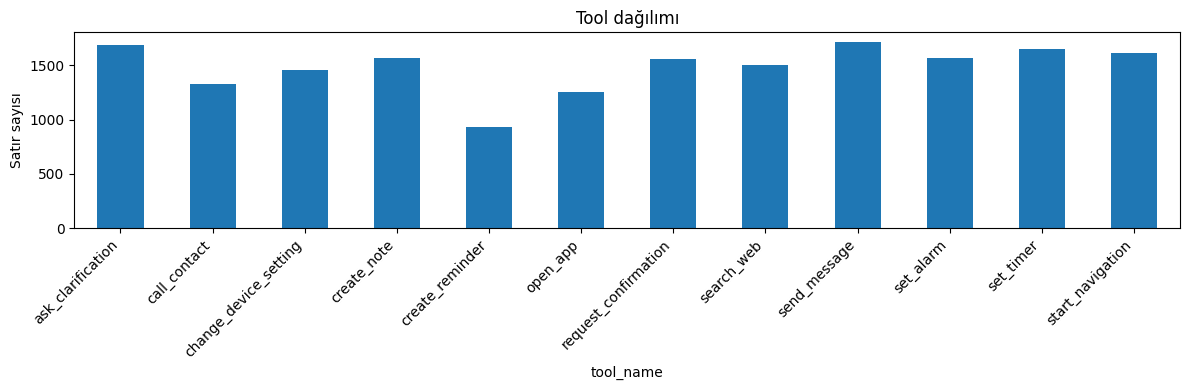

In [7]:
tool_counts = df["tool_name"].value_counts().sort_index()
print("Tool dağılımı:")
print(tool_counts)

plt.figure(figsize=(12, 4))
tool_counts.plot(kind="bar")
plt.title("Tool dağılımı")
plt.ylabel("Satır sayısı")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Train/Test Split

`train_test_split` stratify ile denenir. Az örnekli sınıf yüzünden hata oluşursa otomatik olarak `stratify=None` fallback yapılır.

In [8]:
def fallback_train_test_split(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """sklearn yoksa basit shuffle train/test split yapar.

    Args:
        df: Temiz dataset.

    Returns:
        Train ve test DataFrame ikilisi.
    """
    shuffled = df.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)
    test_count = max(1, int(round(len(shuffled) * TEST_SIZE)))
    return shuffled.iloc[test_count:].reset_index(drop=True), shuffled.iloc[:test_count].reset_index(drop=True)


if train_test_split is None:
    train_df, test_df = fallback_train_test_split(df)
else:
    try:
        train_df, test_df = train_test_split(
            df,
            test_size=TEST_SIZE,
            shuffle=True,
            random_state=RANDOM_SEED,
            stratify=df["tool_name"],
        )
        print("Stratified split kullanıldı.")
    except Exception as exc:
        print(f"Stratified split başarısız, stratify=None fallback: {exc}")
        train_df, test_df = train_test_split(
            df,
            test_size=TEST_SIZE,
            shuffle=True,
            random_state=RANDOM_SEED,
            stratify=None,
        )

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(f"Train satır: {len(train_df)} | Test satır: {len(test_df)}")
print("\nTrain tool dağılımı:")
print(train_df["tool_name"].value_counts().sort_index())
print("\nTest tool dağılımı:")
print(test_df["tool_name"].value_counts().sort_index())

Stratified split kullanıldı.
Train satır: 16043 | Test satır: 1783

Train tool dağılımı:
tool_name
ask_clarification        1517
call_contact             1194
change_device_setting    1310
create_note              1409
create_reminder           842
open_app                 1126
request_confirmation     1399
search_web               1351
send_message             1545
set_alarm                1408
set_timer                1488
start_navigation         1454
Name: count, dtype: int64

Test tool dağılımı:
tool_name
ask_clarification        169
call_contact             133
change_device_setting    145
create_note              157
create_reminder           93
open_app                 125
request_confirmation     155
search_web               150
send_message             172
set_alarm                157
set_timer                165
start_navigation         162
Name: count, dtype: int64


## 9. Qwen Chat Dataset Formatı

FunctionGemma `tool_calls` formatı kullanılmaz. Her örnek Qwen chat template içine `system`, `user`, `assistant` mesajları olarak verilir. Assistant hedefi minified tek satır JSON string'dir.

In [9]:
def build_target_json(row: dict[str, Any] | pd.Series) -> str:
    """Satırdan assistant hedef JSON string üretir.

    Args:
        row: user/tool satırı.

    Returns:
        Minified JSON string.
    """
    args = safe_json_loads(row["tool_arguments"])
    target = {"name": row["tool_name"], "arguments": args}
    return json.dumps(target, ensure_ascii=False, separators=(",", ":"))


def create_messages(row: dict[str, Any] | pd.Series) -> list[dict[str, str]]:
    """Qwen chat messages formatına tek satırı dönüştürür.

    Args:
        row: Dataset satırı.

    Returns:
        system/user/assistant mesaj listesi.
    """
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": str(row["user_content"])},
        {"role": "assistant", "content": build_target_json(row)},
    ]


def add_messages(example: dict[str, Any]) -> dict[str, Any]:
    """Hugging Face Dataset map için messages kolonu ekler.

    Args:
        example: Dataset örneği.

    Returns:
        messages eklenmiş örnek.
    """
    example["messages"] = create_messages(example)
    example["target_json"] = build_target_json(example)
    return example


train_dataset = Dataset.from_pandas(train_df, preserve_index=False).map(add_messages)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False).map(add_messages)
print(train_dataset)
print(test_dataset)
print("Örnek target:", train_dataset[0]["target_json"])

Map:   0%|          | 0/16043 [00:00<?, ? examples/s]

Map:   0%|          | 0/1783 [00:00<?, ? examples/s]

Dataset({
    features: ['user_content', 'tool_name', 'tool_arguments', 'original_tool_name', 'normalization_note', 'messages', 'target_json'],
    num_rows: 16043
})
Dataset({
    features: ['user_content', 'tool_name', 'tool_arguments', 'original_tool_name', 'normalization_note', 'messages', 'target_json'],
    num_rows: 1783
})
Örnek target: {"name":"set_alarm","arguments":{"time":"14:15","date":"tomorrow","label":"randevu"}}


## 10. Tokenizer ve Model Yükleme

In [10]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False

print("Tokenizer pad token:", tokenizer.pad_token)
print("Model dtype:", next(model.parameters()).dtype)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Tokenizer pad token: <|endoftext|>
Model dtype: torch.float16


## 11. LoRA Config

Tam fine-tune yapılmaz. P100/T4 gibi 16GB GPU'larda çalışabilmesi için PEFT LoRA kullanılır.

In [11]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)
print(lora_config)

LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.19.1', base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules={'up_proj', 'gate_proj', 'q_proj', 'o_proj', 'k_proj', 'down_proj', 'v_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)


## 12. Prompt Formatting Kontrolü

Assistant mesajında yalnızca minified JSON görünmeli.

In [12]:
sample_messages = train_dataset[0]["messages"]
formatted_prompt = tokenizer.apply_chat_template(
    sample_messages,
    tokenize=False,
    add_generation_prompt=False,
)
print(formatted_prompt)
print("\nAssistant target JSON:")
print(sample_messages[-1]["content"])

<|im_start|>system
Sen Türkçe mobil komutları function call JSON formatına çeviren bir modelsin. Kullanıcıya açıklama yapma. Sadece geçerli JSON üret. JSON formatı şu olmalı: {"name":"tool_name","arguments":{...}}. Eğer bilgi eksikse ask_clarification kullan. Riskli işlemde request_confirmation kullan.<|im_end|>
<|im_start|>user
Yarın 14:15'e randevu<|im_end|>
<|im_start|>assistant
{"name":"set_alarm","arguments":{"time":"14:15","date":"tomorrow","label":"randevu"}}<|im_end|>


Assistant target JSON:
{"name":"set_alarm","arguments":{"time":"14:15","date":"tomorrow","label":"randevu"}}


## 13. Evaluation Helper Fonksiyonları

Before/after ölçümde JSON valid rate, tool accuracy, argument exact accuracy ve both accuracy hesaplanır.

In [13]:
def get_model_device(model: torch.nn.Module) -> torch.device:
    """Model parametrelerinden aktif cihazı bulur.

    Args:
        model: PyTorch model.

    Returns:
        Model cihazı.
    """
    return next(model.parameters()).device


def generate_output(model: torch.nn.Module, tokenizer: Any, user_content: str) -> str:
    """Modelden tek kullanıcı komutu için assistant çıktısı üretir.

    Args:
        model: Qwen veya LoRA adapter uygulanmış model.
        tokenizer: Qwen tokenizer.
        user_content: Kullanıcı komutu.

    Returns:
        Üretilen raw assistant text.
    """
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(get_model_device(model))
    model.eval()
    with torch.no_grad():
        generated = model.generate(
            **inputs,
            do_sample=False,
            max_new_tokens=128,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = generated[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


def extract_json_from_output(output_text: str) -> dict[str, Any] | None:
    """Model çıktısından ilk valid JSON object'i brace matching ile çıkarır.

    Args:
        output_text: Modelin raw text çıktısı.

    Returns:
        Parse edilmiş JSON dict veya None.
    """
    starts = [idx for idx, char in enumerate(output_text) if char == "{"]
    for start in starts:
        depth = 0
        in_string = False
        escape = False
        for end in range(start, len(output_text)):
            char = output_text[end]
            if escape:
                escape = False
                continue
            if char == "\\":
                escape = True
                continue
            if char == '"':
                in_string = not in_string
                continue
            if in_string:
                continue
            if char == "{":
                depth += 1
            elif char == "}":
                depth -= 1
                if depth == 0:
                    candidate = output_text[start:end + 1]
                    try:
                        parsed = json.loads(candidate)
                        return parsed if isinstance(parsed, dict) else None
                    except Exception:
                        break
    return None


def normalize_json(value: Any) -> dict[str, Any]:
    """Dict veya JSON string değeri dict'e normalize eder.

    Args:
        value: Dict, JSON string veya boş değer.

    Returns:
        Normalize edilmiş dict.
    """
    if isinstance(value, dict):
        return value
    if isinstance(value, str) and value.strip():
        parsed = json.loads(value)
        return parsed if isinstance(parsed, dict) else {}
    return {}


def evaluate_rows(
    model: torch.nn.Module,
    tokenizer: Any,
    rows: pd.DataFrame,
    max_samples: int | None = None,
    print_errors: bool = False,
) -> tuple[dict[str, float], pd.DataFrame]:
    """Satır bazında JSON router performansını ölçer.

    Args:
        model: Değerlendirilecek model.
        tokenizer: Tokenizer.
        rows: user_content/tool_name/tool_arguments içeren DataFrame.
        max_samples: Değerlendirilecek maksimum örnek sayısı.
        print_errors: İlk hataları ekrana yazdırma bayrağı.

    Returns:
        Metrics sözlüğü ve error DataFrame.
    """
    eval_rows = rows.reset_index(drop=True)
    if max_samples is not None and len(eval_rows) > max_samples:
        eval_rows = eval_rows.sample(n=max_samples, random_state=RANDOM_SEED).reset_index(drop=True)

    total = len(eval_rows)
    json_valid_count = 0
    tool_correct_count = 0
    args_exact_count = 0
    both_count = 0
    errors: list[dict[str, Any]] = []

    for _, row in tqdm(eval_rows.iterrows(), total=total, desc="Evaluating"):
        expected_name = row["tool_name"]
        expected_args = safe_json_loads(row["tool_arguments"])
        output = generate_output(model, tokenizer, row["user_content"])
        pred_json = extract_json_from_output(output)

        json_valid = pred_json is not None
        pred_name = pred_json.get("name") if isinstance(pred_json, dict) else None
        pred_args = pred_json.get("arguments") if isinstance(pred_json, dict) else None
        pred_args = pred_args if isinstance(pred_args, dict) else None

        tool_correct = pred_name == expected_name
        args_exact = pred_args == expected_args
        both = tool_correct and args_exact

        json_valid_count += int(json_valid)
        tool_correct_count += int(tool_correct)
        args_exact_count += int(args_exact)
        both_count += int(both)

        if not both:
            errors.append(
                {
                    "user_content": row["user_content"],
                    "expected_name": expected_name,
                    "expected_args": json.dumps(expected_args, ensure_ascii=False, sort_keys=True),
                    "pred_name": pred_name,
                    "pred_args": json.dumps(pred_args, ensure_ascii=False, sort_keys=True) if isinstance(pred_args, dict) else None,
                    "json_valid": json_valid,
                    "raw_output": output,
                }
            )

    denom = max(total, 1)
    metrics = {
        "samples": float(total),
        "tool_accuracy": tool_correct_count / denom,
        "args_exact_accuracy": args_exact_count / denom,
        "both_accuracy": both_count / denom,
        "json_valid_rate": json_valid_count / denom,
    }
    errors_df = pd.DataFrame(errors)
    if print_errors and not errors_df.empty:
        display(errors_df.head(10))
    print(metrics)
    return metrics, errors_df


def save_errors(errors_df: pd.DataFrame, path: str) -> None:
    """Error DataFrame'i CSV olarak kaydeder.

    Args:
        errors_df: Hata kayıtları.
        path: Kaydedilecek CSV path'i.

    Returns:
        Yok.
    """
    errors_df.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"Hata dosyası kaydedildi: {path} | satır={len(errors_df)}")

## 14. Before Fine-tune Evaluation

Base modelin doğrudan JSON router görevindeki performansı ölçülür. Bu hücre 50 test örneğiyle sınırlıdır.

In [14]:
before_metrics, before_errors_df = evaluate_rows(
    model,
    tokenizer,
    test_df,
    max_samples=50,
    print_errors=True,
)
print("Before fine-tune metrics:", before_metrics)

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

,user_content,expected_name,expected_args,pred_name,pred_args,json_valid,raw_output
0,İlaçlar başlığına d vitamini damlası günde bir...,create_note,"{""content"": ""d vitamini damlası günde bir kez ...",D Vitamini Yeniden Alım,"{""frequency"": ""Güneya Bir Kez""}",True,"{\n ""name"": ""D Vitamini Yeniden Alım"",\n ""ar..."
1,"Bakkal listesi diye kaydet, notta kahvaltılık ...",create_note,"{""content"": ""kahvaltılık gevrek, bal, tereyağı...",bakiyeniz,"{""bal"": ""bal"", ""notat"": ""nota kahvaltı"", ""tere...",True,"{""name"":""bakiyeniz"",""arguments"":{""notat"":""nota..."
2,Kitap okuma için 25 dakika sonra çalacak zaman...,set_timer,"{""duration_minutes"": 25, ""label"": ""kitap okuma""}",time-logger,"{""duration"": 25}",True,"{""name"":""time-logger"",""arguments"":{""duration"":..."
3,MNG Kargo için yaya navigasyonu aç,start_navigation,"{""destination"": ""MNG Kargo"", ""mode"": ""walking""}",yaya_navigasyon_ac,"{""kargo_kodu"": ""1234567890""}",True,"{""name"":""yaya_navigasyon_ac"",""arguments"":{""kar..."
4,Kankama nerdesin de,send_message,"{""app"": ""sms"", ""message"": ""nerdesin"", ""recipie...",kancam,{},True,"{""name"":""kancam"", ""arguments"":{}}"
5,Gazanfer'e sms gönder seçim sonuçları açıklandı,send_message,"{""app"": ""sms"", ""message"": ""Seçim sonuçları açı...",sms_send_result,"{""message"": ""İşlem Başarıyla Gerçekleşti"", ""sm...",True,"{""name"":""sms_send_result"",""arguments"":{""sms_nu..."
6,kahve için 2 dakika zamanlayıcı başlat,set_timer,"{""duration_minutes"": 2, ""label"": ""kahve""}",startTimer,"{""durationInMinutes"": 2, ""intervalInSeconds"": ...",True,"{""name"":""startTimer"",""arguments"":{""durationInM..."
7,Medya indirilenleri sil,request_confirmation,"{""action"": ""medya indirilenlerini sil"", ""quest...",medya,"{""action"": ""sil""}",True,"{""name"":""medya"",""arguments"":{""action"":""sil""}}"
8,Mercimek çorbası nasıl yapılır,search_web,"{""query"": ""Kolay mercimek çorbası tarifi""}",NaN,NaN,False,"Merkezi çorbası, merkezlerin içini ve dışını d..."
9,Dosyalar'ı başlat,open_app,"{""app_name"": ""Dosyalar""}",start_file,"{""file_path"": ""/path/to/your/file.txt""}",True,"{""name"":""start_file"",""arguments"":{""file_path"":..."


{'samples': 50.0, 'tool_accuracy': 0.0, 'args_exact_accuracy': 0.0, 'both_accuracy': 0.0, 'json_valid_rate': 0.94}
Before fine-tune metrics: {'samples': 50.0, 'tool_accuracy': 0.0, 'args_exact_accuracy': 0.0, 'both_accuracy': 0.0, 'json_valid_rate': 0.94}


## 15. SFTConfig

TRL sürüm farkları için `eval_strategy` / `evaluation_strategy` gibi parametreler imzaya göre filtrelenir.

In [15]:
def build_sft_config() -> SFTConfig:
    """Kurulu TRL sürümüyle uyumlu SFTConfig oluşturur.

    Args:
        Yok.

    Returns:
        SFTConfig nesnesi.
    """
    supports_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
    kwargs: dict[str, Any] = {
        "output_dir": CHECKPOINT_DIR,
        "num_train_epochs": NUM_TRAIN_EPOCHS,
        "per_device_train_batch_size": PER_DEVICE_TRAIN_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "learning_rate": LEARNING_RATE,
        "lr_scheduler_type": "cosine",
        "warmup_ratio": 0.05,
        "logging_steps": LOGGING_STEPS,
        "eval_strategy": "steps",
        "eval_steps": EVAL_STEPS,
        "save_strategy": "steps",
        "save_steps": SAVE_STEPS,
        "save_total_limit": 2,
        "load_best_model_at_end": True,
        "metric_for_best_model": "eval_loss",
        "greater_is_better": False,
        "fp16": torch.cuda.is_available() and not supports_bf16,
        "bf16": supports_bf16,
        "gradient_checkpointing": True,
        "max_length": MAX_LENGTH,
        "packing": False,
        "report_to": "tensorboard",
        "push_to_hub": PUSH_TO_HUB,
        "hub_model_id": HUB_MODEL_ID if PUSH_TO_HUB else None,
    }

    signature = inspect.signature(SFTConfig.__init__)
    params = set(signature.parameters)
    if "eval_strategy" not in params and "evaluation_strategy" in params:
        kwargs["evaluation_strategy"] = kwargs.pop("eval_strategy")
    filtered = {key: value for key, value in kwargs.items() if key in params and value is not None}
    dropped = sorted(set(kwargs) - set(filtered))
    if dropped:
        print("Bu TRL sürümünde atlanan SFTConfig parametreleri:", dropped)
    return SFTConfig(**filtered)


sft_config = build_sft_config()
print(sft_config)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Bu TRL sürümünde atlanan SFTConfig parametreleri: ['hub_model_id']
SFTConfig(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
activation_offloading=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
assistant_only_loss=False,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=True,
bf16_full_eval=False,
chat_template_path=None,
completion_only_loss=None,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
dataset_kwargs=None,
dataset_num_proc=None,
dataset_text_field=text,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=Fa

## 16. TrainerCallback

Her evaluation adımında 50 test örneğiyle hızlı tool accuracy ölçümü yapılır.

In [16]:
class ToolAccuracyCallback(TrainerCallback):
    """Evaluation sonunda küçük örneklem üzerinde JSON router metric basar.

    Args:
        tokenizer: Evaluation için tokenizer.
        eval_rows: Test DataFrame.
        max_samples: Callback başına değerlendirilecek örnek sayısı.
    """

    def __init__(self, tokenizer: Any, eval_rows: pd.DataFrame, max_samples: int = 50) -> None:
        self.tokenizer = tokenizer
        self.eval_rows = eval_rows
        self.max_samples = max_samples

    def on_evaluate(self, args: Any, state: Any, control: Any, **kwargs: Any) -> None:
        """Trainer evaluate çağrısından sonra metric hesaplar."""
        callback_model = kwargs.get("model")
        if callback_model is None:
            return
        print("\nCallback JSON router evaluation:")
        evaluate_rows(callback_model, self.tokenizer, self.eval_rows, max_samples=self.max_samples, print_errors=False)

## 17. SFTTrainer

In [17]:
trainer_kwargs = {
    "model": model,
    "args": sft_config,
    "train_dataset": train_dataset,
    "eval_dataset": test_dataset,
    "peft_config": lora_config,
    "callbacks": [ToolAccuracyCallback(tokenizer, test_df, max_samples=50)],
}

trainer_signature = inspect.signature(SFTTrainer.__init__)
trainer_params = set(trainer_signature.parameters)
if "processing_class" in trainer_params:
    trainer_kwargs["processing_class"] = tokenizer
else:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = SFTTrainer(**trainer_kwargs)
print("Trainer hazır.")

Tokenizing train dataset:   0%|          | 0/16043 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1783 [00:00<?, ? examples/s]

Trainer hazır.


## 18. Train

In [18]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

trainer.train()
trainer.save_model(CHECKPOINT_DIR)
tokenizer.save_pretrained(CHECKPOINT_DIR)

if PUSH_TO_HUB:
    trainer.push_to_hub()

print(f"Model/adapters kaydedildi: {CHECKPOINT_DIR}")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss,Validation Loss


KeyboardInterrupt: 

In [20]:
from huggingface_hub import login, create_repo, upload_folder
from pathlib import Path
import os
import json

PUSH_TO_HUB_NOW = True

CHECKPOINT_PATH = Path(CHECKPOINT_DIR)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)

# Train hücresi zaten kaydetti; burada upload öncesi tekrar garantiye alıyoruz.
trainer.save_model(CHECKPOINT_DIR)
tokenizer.save_pretrained(CHECKPOINT_DIR)

HF_TOKEN = None
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")

if PUSH_TO_HUB_NOW:
    if not HF_TOKEN:
        raise ValueError("HF_TOKEN bulunamadı. Colab Secrets içine HF_TOKEN ekle.")

    login(token=HF_TOKEN)

    create_repo(
        repo_id=HUB_MODEL_ID,
        token=HF_TOKEN,
        repo_type="model",
        private=False,
        exist_ok=True,
    )

    before_metrics_safe = globals().get("before_metrics", {})
    tool_distribution_safe = df["tool_name"].value_counts().sort_index().to_dict()
    tool_distribution_md = "\n".join(
        f"| {tool} | {count} |" for tool, count in tool_distribution_safe.items()
    )

    preliminary_readme = f"""---
license: apache-2.0
base_model: {BASE_MODEL}
language:
- tr
library_name: peft
tags:
- qwen
- qwen2.5
- lora
- peft
- function-calling
- action-router
- turkish
- mobile-actions
- json
pipeline_tag: text-generation
---

# Qwen2.5 0.5B Turkish Mobile Action Router LoRA

This repository contains a LoRA adapter fine-tuned from `{BASE_MODEL}` for Turkish mobile function-calling / action-routing.

The model is trained to produce a single-line JSON router output. It does **not** use FunctionGemma special tokens or FunctionGemma `tool_calls` format.

## Target Format

```json
{{"name":"tool_name","arguments":{{...}}}}
```

Example:

```json
{{"name":"set_alarm","arguments":{{"time":"08:00","date":"tomorrow","label":null}}}}
```

## System Prompt

```text
{SYSTEM_PROMPT}
```

## Allowed Tools

- `set_alarm`
- `set_timer`
- `create_reminder`
- `send_message`
- `call_contact`
- `open_app`
- `change_device_setting`
- `create_note`
- `start_navigation`
- `search_web`
- `ask_clarification`
- `request_confirmation`

## Dataset

The dataset was built from multiple CSV/XLSX files in `./csv_datasets`.

Expected columns:

- `user_content`
- `tool_name`
- `tool_arguments`

Dataset cleaning included:

- Empty row removal
- Duplicate row removal
- Tool name validation
- JSON parsing for `tool_arguments`
- Required argument validation
- Normalization of older tool schemas into the final allowed tool set

## Dataset Size

- Total clean rows: **{len(df)}**
- Train rows: **{len(train_df)}**
- Test rows: **{len(test_df)}**

## Tool Distribution

| Tool | Rows |
|---|---:|
{tool_distribution_md}

## Training

Training type: **LoRA / PEFT adapter**

| Parameter | Value |
|---|---:|
| Base model | `{BASE_MODEL}` |
| Epochs | {NUM_TRAIN_EPOCHS} |
| Learning rate | {LEARNING_RATE} |
| Max length | {MAX_LENGTH} |
| Train batch size | {PER_DEVICE_TRAIN_BATCH_SIZE} |
| Gradient accumulation | {GRADIENT_ACCUMULATION_STEPS} |

## Preliminary Evaluation

Before fine-tuning metrics, if available:

```json
{json.dumps(before_metrics_safe, indent=2, ensure_ascii=False)}
```

Final evaluation artifacts and plots can be uploaded after running the after-fine-tune evaluation cells.

## Usage

```python
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

BASE_MODEL = "{BASE_MODEL}"
ADAPTER_ID = "{HUB_MODEL_ID}"

system_prompt = {json.dumps(SYSTEM_PROMPT, ensure_ascii=False)}

tokenizer = AutoTokenizer.from_pretrained(ADAPTER_ID, trust_remote_code=True)

base = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True,
)

model = PeftModel.from_pretrained(base, ADAPTER_ID)
model.eval()

messages = [
    {{"role": "system", "content": system_prompt}},
    {{"role": "user", "content": "Yarın sabah 8'e alarm kur"}},
]

prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    output = model.generate(
        **inputs,
        do_sample=False,
        max_new_tokens=128,
        pad_token_id=tokenizer.eos_token_id,
    )

generated = output[0][inputs["input_ids"].shape[-1]:]
print(tokenizer.decode(generated, skip_special_tokens=True).strip())
```

## Notes

This is an action-router model, not a general chat assistant. It should output JSON only. Risky actions should be routed to `request_confirmation`.
"""

    readme_path = CHECKPOINT_PATH / "README.md"
    with open(readme_path, "w", encoding="utf-8") as file:
        file.write(preliminary_readme)

    upload_folder(
        repo_id=HUB_MODEL_ID,
        folder_path=str(CHECKPOINT_PATH),
        repo_type="model",
        token=HF_TOKEN,
        commit_message="Upload Qwen2.5 Turkish mobile action-router LoRA adapter",
    )

    print("Model/adapters Hub'a yüklendi:")
    print(f"https://huggingface.co/{HUB_MODEL_ID}")
else:
    print("PUSH_TO_HUB_NOW=False, upload atlandı.")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 38.0kB / 35.2MB            

  ...ckpoint-2169/optimizer.pt:   1%|          |  573kB / 70.7MB            

  ...ckpoint-2000/optimizer.pt:   1%|          |  569kB / 70.7MB            

...

  ...adapter_model.safetensors:   0%|          | 38.0kB / 35.2MB            

  ...adapter_model.safetensors:   0%|          | 38.0kB / 35.2MB            

  ...01247.f2d70655ec60.1419.0:  11%|#1        | 4.81kB / 43.6kB            

  ...actions/training_args.bin:   1%|1         |  76.0B / 5.78kB            

Model/adapters Hub'a yüklendi:
https://huggingface.co/BTX24/qwen2_5_0_5b_turkish-mobile-actions


## 19. Loss Plot

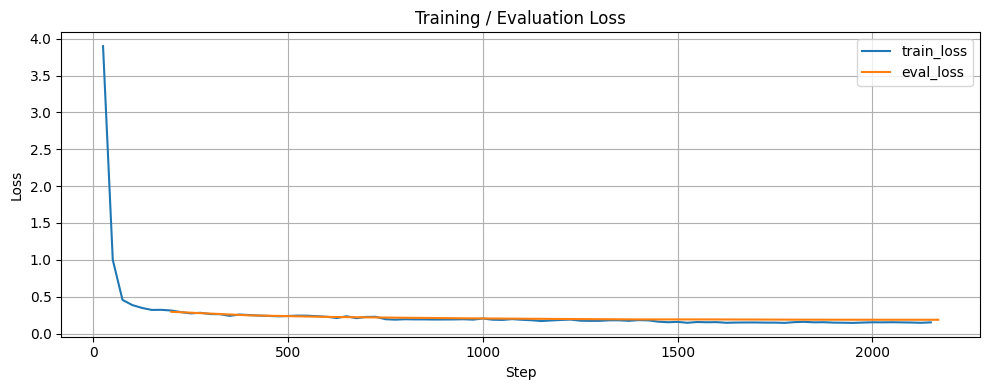

In [21]:
log_history = trainer.state.log_history
train_steps = [item["step"] for item in log_history if "loss" in item]
train_losses = [item["loss"] for item in log_history if "loss" in item]
eval_steps_list = [item["step"] for item in log_history if "eval_loss" in item]
eval_losses = [item["eval_loss"] for item in log_history if "eval_loss" in item]

plt.figure(figsize=(10, 4))
if train_losses:
    plt.plot(train_steps, train_losses, label="train_loss")
if eval_losses:
    plt.plot(eval_steps_list, eval_losses, label="eval_loss")
plt.title("Training / Evaluation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 20. After Fine-tune Evaluation

Tüm test setinde JSON router performansı ölçülür. Hatalar ve metric JSON dosyaya kaydedilir.

In [22]:
after_metrics, after_errors_df = evaluate_rows(
    trainer.model,
    tokenizer,
    test_df,
    max_samples=None,
    print_errors=True,
)
save_errors(after_errors_df, ERRORS_AFTER_PATH)

all_metrics = {
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "before": before_metrics,
    "after": after_metrics,
    "tool_distribution": tool_counts.to_dict(),
    "errors_after_path": ERRORS_AFTER_PATH,
}
with open(METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(all_metrics, file, indent=2, ensure_ascii=False)
print(f"Metrics kaydedildi: {METRICS_PATH}")
print(json.dumps(all_metrics, indent=2, ensure_ascii=False))

Evaluating:   0%|          | 0/1286 [00:00<?, ?it/s]

,user_content,expected_name,expected_args,pred_name,pred_args,json_valid,raw_output
0,eve nsl giderim,start_navigation,"{""destination"": ""Ev"", ""mode"": ""driving""}",ask_clarification,"{""missing_field"": ""text"", ""question"": ""Neyi ne...",True,"{""name"":""ask_clarification"",""arguments"":{""miss..."
1,Aileden birini ara,ask_clarification,"{""missing_field"": ""recipient"", ""question"": ""Ai...",ask_clarification,"{""missing_field"": ""recipient"", ""question"": ""Ki...",True,"{""name"":""ask_clarification"",""arguments"":{""miss..."
2,Oyun için 45 dk timer,set_timer,"{""duration_minutes"": 45, ""label"": ""Oyun""}",set_timer,"{""duration_minutes"": 45, ""label"": ""oyun""}",True,"{""name"":""set_timer"",""arguments"":{""duration_min..."
3,Onda beni uyar,set_alarm,"{""date"": ""today_or_next_occurrence"", ""label"": ...",set_alarm,"{""date"": ""sunday"", ""label"": null, ""time"": ""20:...",True,"{""name"":""set_alarm"",""arguments"":{""time"":""20:00..."
4,Toplantı belgesi aç,ask_clarification,"{""missing_field"": ""title"", ""question"": ""Toplan...",ask_clarification,"{""missing_field"": ""recipient_and_message"", ""qu...",True,"{""name"":""ask_clarification"",""arguments"":{""miss..."
5,Kapadokya balon turu fiyatı,search_web,"{""query"": ""Kapadokya sıcak hava balonu turu fi...",search_web,"{""query"": ""Kapadokya balon turu fiyatı""}",True,"{""name"":""search_web"",""arguments"":{""query"":""Kap..."
6,internetimi paylaşma,ask_clarification,"{""missing_field"": ""value"", ""question"": ""İntern...",change_device_setting,"{""setting"": ""hotspot"", ""value"": ""off""}",True,"{""name"":""change_device_setting"",""arguments"":{""..."
7,Komşuya mesaj at,ask_clarification,"{""missing_field"": ""message"", ""question"": ""Komş...",ask_clarification,"{""missing_field"": ""message"", ""question"": ""Hang...",True,"{""name"":""ask_clarification"",""arguments"":{""miss..."
8,Not uygulamasına fizyoterapiste bel ağrısının ...,create_note,"{""content"": ""fizyoterapiste bel ağrısının hang...",create_note,"{""content"": ""fizyoterapiste bel ağrısının hang...",True,"{""name"":""create_note"",""arguments"":{""title"":nul..."
9,Haber ara,ask_clarification,"{""missing_field"": ""query"", ""question"": ""Hangi ...",ask_clarification,"{""missing_field"": ""query"", ""question"": ""Hangi ...",True,"{""name"":""ask_clarification"",""arguments"":{""miss..."


{'samples': 1286.0, 'tool_accuracy': 0.9743390357698289, 'args_exact_accuracy': 0.8297045101088647, 'both_accuracy': 0.8297045101088647, 'json_valid_rate': 0.9992223950233281}
Hata dosyası kaydedildi: errors_qwen_after_finetune.csv | satır=219
Metrics kaydedildi: qwen_eval_metrics.json
{
  "train_rows": 11568,
  "test_rows": 1286,
  "before": {
    "samples": 50.0,
    "tool_accuracy": 0.0,
    "args_exact_accuracy": 0.0,
    "both_accuracy": 0.0,
    "json_valid_rate": 0.96
  },
  "after": {
    "samples": 1286.0,
    "tool_accuracy": 0.9743390357698289,
    "args_exact_accuracy": 0.8297045101088647,
    "both_accuracy": 0.8297045101088647,
    "json_valid_rate": 0.9992223950233281
  },
  "tool_distribution": {
    "ask_clarification": 1686,
    "call_contact": 1327,
    "change_device_setting": 1455,
    "create_note": 666,
    "create_reminder": 663,
    "open_app": 1251,
    "request_confirmation": 206,
    "search_web": 901,
    "send_message": 1717,
    "set_alarm": 879,
    "set

## 21. Manual Test

In [23]:
def test_prompt(prompt: str) -> dict[str, Any] | None:
    """Manuel prompt için model çıktısını üretir ve JSON parse eder.

    Args:
        prompt: Türkçe mobil komut.

    Returns:
        Parse edilmiş JSON veya None.
    """
    output = generate_output(trainer.model, tokenizer, prompt)
    parsed = extract_json_from_output(output)
    print("PROMPT:", prompt)
    print("RAW:", output)
    print("JSON:", json.dumps(parsed, ensure_ascii=False) if parsed else None)
    print("-" * 80)
    return parsed


manual_prompts = [
    "Yarın sabah 8'e alarm kur",
    "10 dakikalık zamanlayıcı başlat",
    "Mehmet'e geç kalacağım diye mesaj at",
    "Bluetooth'u aç",
    "Not al: yarın doktor randevusu için tahlil sonuçlarını götür",
    "Eve navigasyon başlat",
    "Bugün İstanbul hava durumu nasıl",
    "Alarm kur",
    "Tüm fotoğrafları sil",
]

for prompt in manual_prompts:
    test_prompt(prompt)

PROMPT: Yarın sabah 8'e alarm kur
RAW: {"name":"set_alarm","arguments":{"time":"08:00","date":"tomorrow","label":null}}
JSON: {"name": "set_alarm", "arguments": {"time": "08:00", "date": "tomorrow", "label": null}}
--------------------------------------------------------------------------------
PROMPT: 10 dakikalık zamanlayıcı başlat
RAW: {"name":"set_timer","arguments":{"duration_minutes":10,"label":null}}
JSON: {"name": "set_timer", "arguments": {"duration_minutes": 10, "label": null}}
--------------------------------------------------------------------------------
PROMPT: Mehmet'e geç kalacağım diye mesaj at
RAW: {"name":"send_message","arguments":{"recipient":"Mehmet","message":"Geç kalacağım.","app":"sms"}}
JSON: {"name": "send_message", "arguments": {"recipient": "Mehmet", "message": "Geç kalacağım.", "app": "sms"}}
--------------------------------------------------------------------------------
PROMPT: Bluetooth'u aç
RAW: {"name":"change_device_setting","arguments":{"setting":"b

## 22. Inference-only Load

Eğitimden sonra LoRA adapter'ı ayrı bir runtime'da şöyle yükleyebilirsin.

In [ ]:
from peft import PeftModel

# Inference-only örnek. Gerektiğinde bu hücreyi ayrı runtime'da çalıştır.
# base = AutoModelForCausalLM.from_pretrained(
#     BASE_MODEL,
#     torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
#     device_map="auto",
#     trust_remote_code=True,
# )
# loaded_model = PeftModel.from_pretrained(base, CHECKPOINT_DIR)
# loaded_tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT_DIR, trust_remote_code=True)
# if loaded_tokenizer.pad_token is None:
#     loaded_tokenizer.pad_token = loaded_tokenizer.eos_token
# loaded_model.config.use_cache = False
# print(generate_output(loaded_model, loaded_tokenizer, "Yarın sabah 8'e alarm kur"))

## 23. Notebook Özeti

Eğitim bittikten sonra aşağıdaki hücre train/test satır sayısını, tool dağılımını, before/after tool accuracy değerlerini, before/after both accuracy değerlerini ve hata dosyası yolunu raporlar.

In [24]:
summary = {
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "tool_distribution": tool_counts.to_dict(),
    "before_tool_accuracy": before_metrics.get("tool_accuracy"),
    "after_tool_accuracy": after_metrics.get("tool_accuracy"),
    "before_both_accuracy": before_metrics.get("both_accuracy"),
    "after_both_accuracy": after_metrics.get("both_accuracy"),
    "bad_rows_path": BAD_ROWS_PATH,
    "errors_after_path": ERRORS_AFTER_PATH,
    "metrics_path": METRICS_PATH,
    "checkpoint_dir": CHECKPOINT_DIR,
}
print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "train_rows": 11568,
  "test_rows": 1286,
  "tool_distribution": {
    "ask_clarification": 1686,
    "call_contact": 1327,
    "change_device_setting": 1455,
    "create_note": 666,
    "create_reminder": 663,
    "open_app": 1251,
    "request_confirmation": 206,
    "search_web": 901,
    "send_message": 1717,
    "set_alarm": 879,
    "set_timer": 1141,
    "start_navigation": 962
  },
  "before_tool_accuracy": 0.0,
  "after_tool_accuracy": 0.9743390357698289,
  "before_both_accuracy": 0.0,
  "after_both_accuracy": 0.8297045101088647,
  "bad_rows_path": "bad_rows_qwen_dataset.csv",
  "errors_after_path": "errors_qwen_after_finetune.csv",
  "metrics_path": "qwen_eval_metrics.json",
  "checkpoint_dir": "qwen2_5_0_5b_turkish_mobile_actions"
}
